# **사이킷런**

<특징>
- 파이썬 기반의 다른 머신러닝 패키지도 사이킷런 스타일의 API를 지향할 정도로 쉽고 가장 파이썬스러운 API를 제공
- 머신러닝을 위한 매우 다양한 알고리즘과 개발을 위한 편리한 프레임워크와 AI기를 제공
- 오랜 기간 실전 환경에서 검증됐으며, 매우 많은 환경에서 사용되는 성숙한 라이브러리

In [4]:
pip install scikit-learn

In [5]:
import sklearn
print(sklearn.__version__)

1.6.1


# 1. 붓꽃 품종 예측하기

분류(Classification): 대표적인 지도학습(Supervised Learning) 방법 중 하나

- 지도학습: 학습을 위한 다양한 피처와 분류 결정값인 레이블(Label) 데이터로 모델을 학습 -> 별도의 테스트 데이터 세트에서 미지의 레이블을 예측
  -  학습을 위해 주어진 데이터 세트 = 학습 데이터 세트
  - 머신러닝 모델의 예측 성능을 평가하기 위해 별도로 주어진 데이터 세트 = 테스트 데이터 세트

- sklearn.tree 내의 모듈: 트리 기반 ML 알고리즘을 구현한 클래스의 모임

- sklearn.model_selection: 학습 데이터와 검증 데이터, 예측 데이터로 데이터를 분리하거나 최적의 하이퍼 파라미터로 평가하기 위한 다양한 모듈의 모임
  - 하이퍼 파라미터: 머신러닝 알고리즘 별로 최적의 학습을 위해 직접 입력하는 파라미터들을 통칭,     머신러닝 알고리즘의 성능 튜닝 가능

- 붓꽃 데이터 세트를 생성: load_iris()를 이용
- ML 알고리즘은 의사 결정 트리(Decision Tree) 알
고리즘으로, 이를 구현한 DecisionTreeClassifier를 적용

In [6]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [7]:
import pandas as pd

# 분꽃 데이터 세트를 로딩합니다.
iris=load_iris()

# iris.data는 Iris 데이터 세트에서 피처(feature)만으로 된 데이터를 numpy로 가지고 있습니다.
iris_data=iris.data

# iris.target은 붓꽃 데이터 세트에서 레이블(결절 값) 데이터를 numpy로 가지고 있습니다.
iris_label=iris.target
print('iris target값:',iris_label)
print('iris target명:',iris.target_names)

# 붓꽃 데이터 세트를 자세히 보기 위해 Dataframe으로 변환합니다.
iris_df=pd.DataFrame(data=iris_data,columns=iris.feature_names)
iris_df['label']=iris.target
iris_df.head(3)


iris target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


학습용 데이터와 테스트용 데이터를 분리
=> 학습 데이터로 학습된 모델이 얼마나 뛰어난 성능을 가지는지 평가하려면 테스트 데이터 세트가 필요하기 때문

- train_test_split()을 이용 - 학습 데이터와 테스트 데이터를 test_size 파라미터 입력값의 비율로 쉽게 분할 (test_size=0.2 : 전체 데이터 중 테스트 데
이터가 20%, 학습 데이터가 80%로 데이터를 분할)

# 학습 데이터 확보

In [8]:
# 학습용 피처 데이터 세트: X_train, 테스트용 피처 데이터 세트: X_test, 학습용 레이블 데이터 세트: y_train, 테스트용 레이블 데이터 세트: y_test
X_train, X_test, y_train, y_test=train_test_split(iris_data,iris_label, test_size=0.2, random_state=11)

- iris_data: 피처 데이터 세트
- irisjabel: 레이블(Label) 데이터 세트
-  test_size=0.2: 테스트 데이터 세트의 비율
- random_state: 호출할 때마다 같은 학습/테스트 용 데이터 세트를 생성하기 위해 주어지는 난수 발생 값
  - train_test_split()는 호출 시 무작위로 데이터를
분리하므로 random_state를 지정하지 않으면 수행할 때마다 다른 학습/테스트 용 데이터를 만들 수 있음




# 위 데이터를 기반으로 머신러닝 분류 알고리즘의 하나인 의사 결정 트리를 이용해 학습과 예측을 수행

In [9]:
# DecisionTreeClassifier 객체 생성
dt_clf=DecisionTreeClassifier(random_state=11)

# 학습 수행
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=11)

In [10]:
# 학습이 완료된 DecisionTreeClassifier 객체에서 테스트 데이터 세트로 예측 수행
pred=dt_clf.predict(X_test)

정확도 = 예측 결과가 실제 레이블 값과 얼마나 정확하게 맞는지를 평가하는 지표
  - accuracy_score() 함수 이용

In [11]:
from sklearn.metrics import accuracy_score
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9333


** 정리 **

1. 데이터 세트 분리: 데이터를 학습 데이터와 테스트 데이터로 분리

 2. 모델 학습: 학습 데이터를 기반으로 ML 알고리즘을 적용해 모델을 학습

 3. 예측 수행: 학습된 ML 모델을 이용해 테스트 데이터의 분류(즉, 붓꽃 종류)를 예측

 4. 평가: 이렇게 예측된 결괏값과 테스트 데이터의 실제 결괏값을 비교해 ML 모델 성능 평가

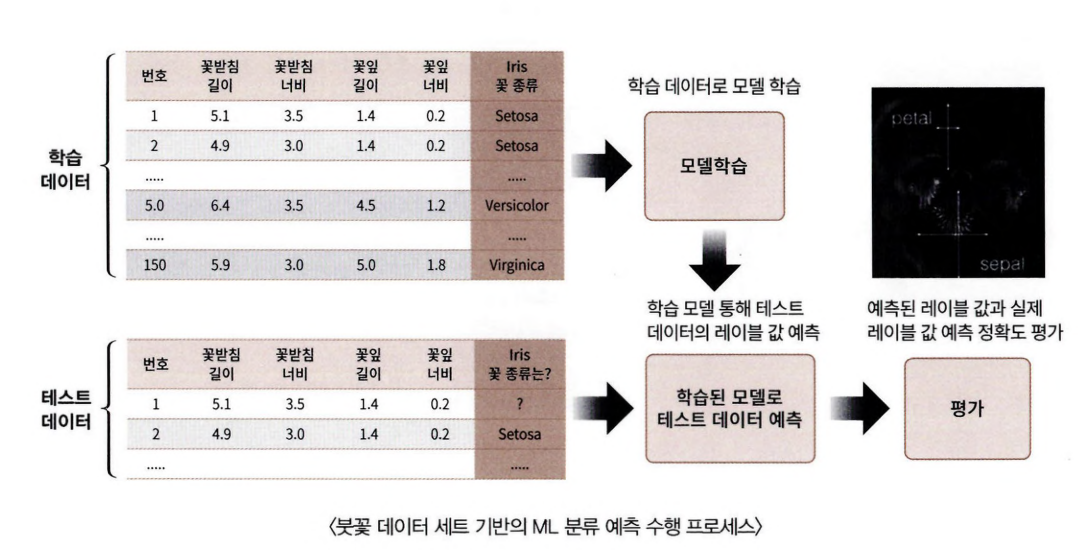

# 2. 사이킷런의 기반 프레임워크 익히기

# Estimator 이해 및 fit(), predict() 메서드

ML 모델 학습 - fit()

학습된 모델 예측 - predict()

지도 학습 - 1. 분류(Classification) / 2. 회귀(Regression)


- 분류 알고리즘을 구현한 클래스: Classifier

- 회귀 알고리즘을 구현한 클래스: Regressor

  - Classifier + Regressor = Estimator

crossjvaljscore( )와 같은 evaluation 함수, GridSearchCV와 같은 하이퍼 파라미터 튜닝을 지원
하는 클래스 - 이 Estimator를 인자로 받음


인자로 받은 Estimator에 대해서 cross_val_
score(), GridSearchCV.fit() 함수 내에서 이 Estimator의 fit()과 predict()를 호출해서 평가를 하
거나 하이퍼 파라미터 튜닝을 수행

비지도학습 = 차원축소, 클러스터링, 피처 추출(Feature Extraction)

- 지도학습의 fit(): 학습
- 비지도학습 & 피처추출의 fit(): 입력 데이터의 형태에 맞춰 데이터를 변환하기 위한 사전 구조를 맞추는 작업
  - fit(): 변환을 위한 사전 구조를 맞추기
  - transform(): 입력 데이터의 차원 변환, 클
러스터 링, 피처 추출 등의 실제 작업 수행
  - fit_transform() = fit() + transform()
  

# 사이킷런의 주요 모듈

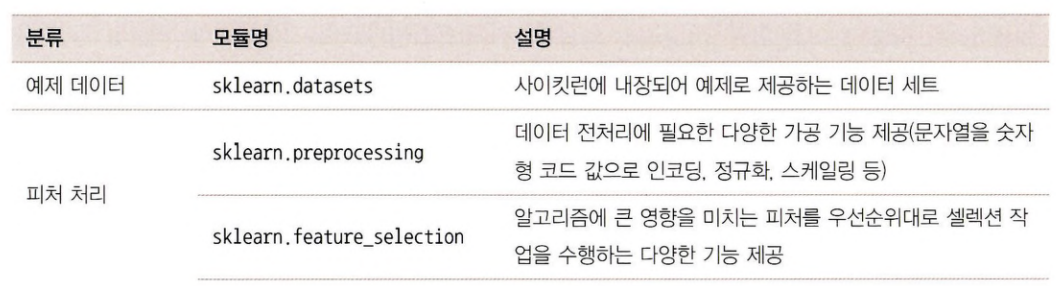

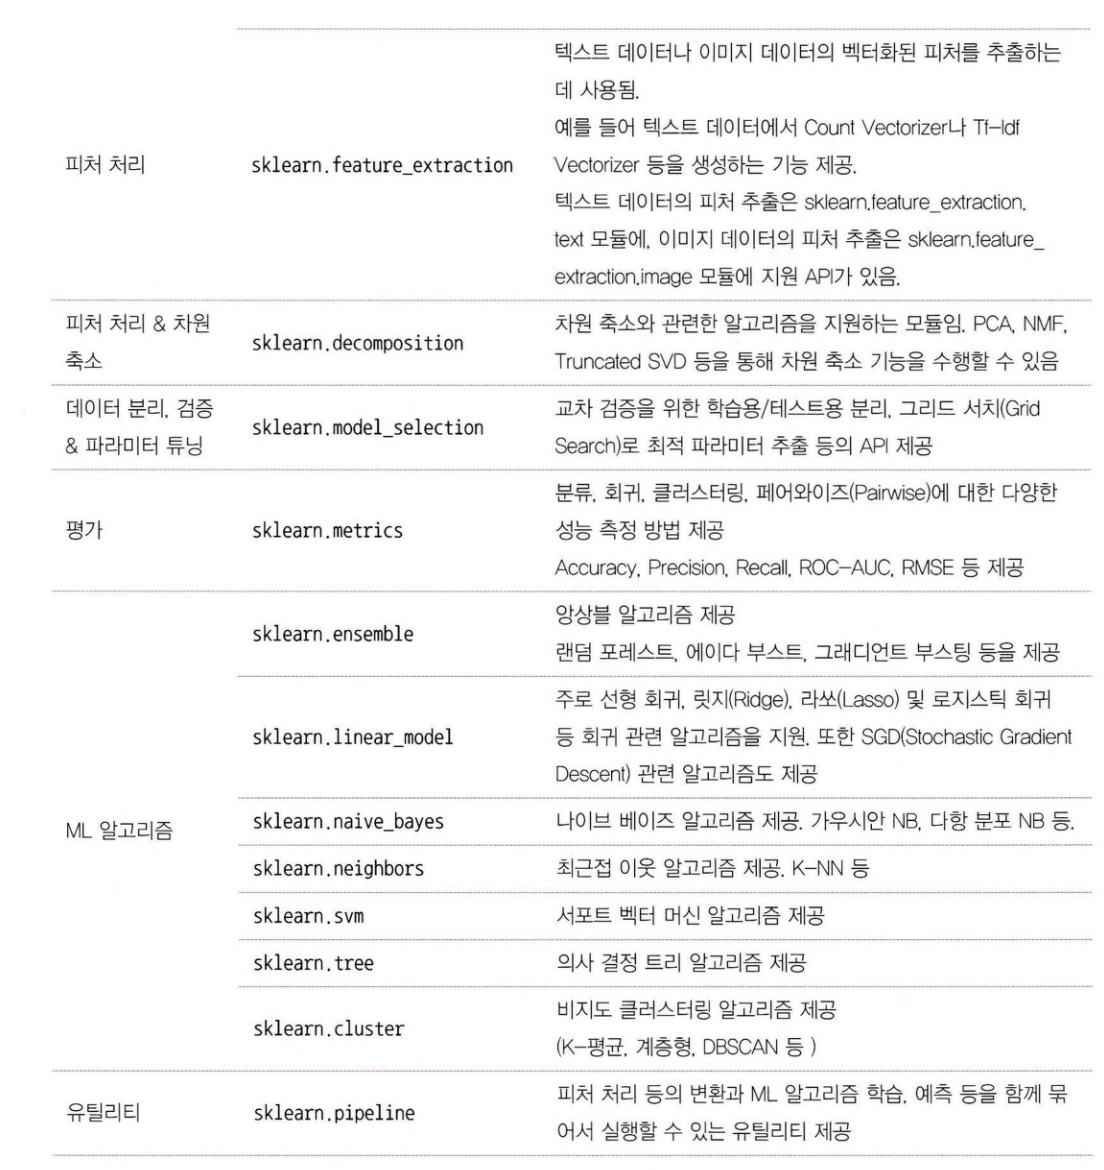

# 내장된 예제 데이터 세트

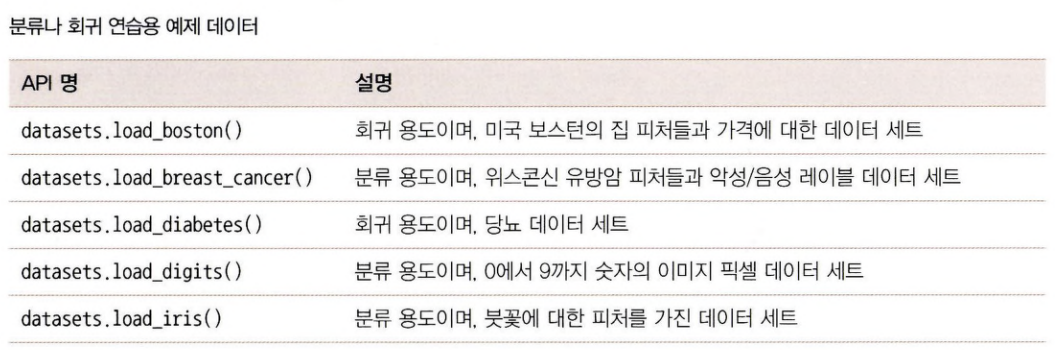

fetch 계열의 명령 = 데이터의 크기가 커서 패키지에 처음부터 저장 X -> 인터넷에서 내려받아 홈 디렉터리 아래의 scikit_learn_data라는 서브 디렉터리에 저장한 후 추후 불러들이는 데이터
- 최초 사용 시 인터넷에 연결되어 있어야 사용 가능

<fetch 계열 명령>
- fetch_covtype(): 회귀 분석용 토지 조사 자료
- fetch_20newsgroups(): 뉴스 그룹 텍스트 자료
- fetch_olivetti_faces(): 얼굴 이미지 자료
- fetch_lfw_people(): 얼굴 이미지 자료
- fetch_rcv1(): 로이터 뉴스 말뭉치
- fetch_mldata(): ML 웹사이트에서 다운로드

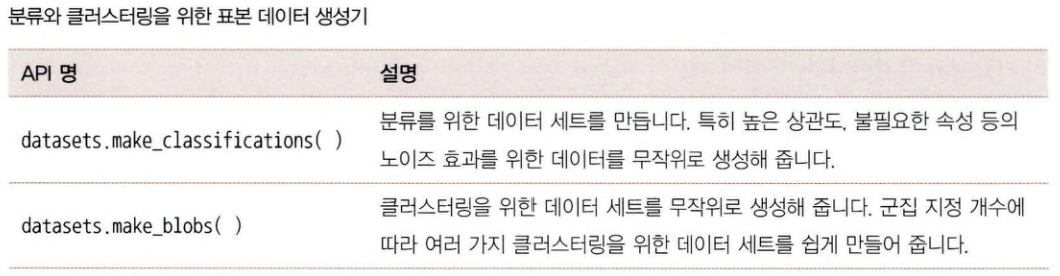

키 =  data, target, target_name, feature_names, DESCR

- data: 피처의 데이터 세트
- target: 분류 시 레이블 값, 회귀 시 숫자 결괏값 데이터 세트
- target_names: 개별 레이블의 이름
- feature_names: 피처의 이름
- DESCR: 데이터 세트에 대한 설명과 각 피처의 설명
  - data, target: 넘파이  배열(ndarray) 타입
  - targetjnames, feature_names: 넘파이 배열 or
파이썬 리스트(list) 타입
  - DESCR: 스트링 타입

In [12]:
from sklearn.datasets import load_iris
iris_data=load_iris()
print(type(iris_data))

<class 'sklearn.utils._bunch.Bunch'>


데이터 세트에 내장돼 있는 대부분의 데이터 세트 = 딕셔너리 형태의 값을 반환
- Bunch 클래스 = 파이썬 딕셔너리 자료형과 유사

In [13]:
keys=iris_data.keys()
print('붓꽃 데이터 세트의 키들:',keys)

붓꽃 데이터 세트의 키들: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [14]:
print('\n feature_names의 type:', type(iris_data.feature_names))
print('feature_names의 shape:', len(iris_data.feature_names))
print(iris_data.feature_names)

print('\n target_names의 type:', type(iris_data.target_names))
print('target_names의 shape:', len(iris_data.target_names))
print(iris_data.target_names)

print('\n data의 type:', type(iris_data.data))
print('data의 shape:', iris_data.data.shape)
print(iris_data['data'])

print('\n target의 type:', type(iris_data.target))
print('target의 shape:', len(iris_data.target))
print(iris_data.target)


 feature_names의 type: <class 'list'>
feature_names의 shape: 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 target_names의 type: <class 'numpy.ndarray'>
target_names의 shape: 3
['setosa' 'versicolor' 'virginica']

 data의 type: <class 'numpy.ndarray'>
data의 shape: (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 

# Model Selection 모듈 소개

# 학습/테스트 데이터 세트 분리 - train_test_split()

In [15]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris=load_iris()
dt_clf=DecisionTreeClassifier()
train_data=iris.data
train_label=iris.target
dt_clf.fit(train_data, train_label)

# 학습된 데이터 세트로 예측 수행
pred=dt_clf.predict(train_data)
print('예측 정확도:', accuracy_score(train_label, pred))

예측 정확도: 1.0


예측 수행 데이터 세트 = 학습용 데이터 X -> 전용의 테스트 데이터 세트 O



In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

dt_clf=DecisionTreeClassifier()
iris_data=load_iris()

X_train, X_test, y_train, y_test=train_test_split(iris_data.data, iris_data.target,
                                                 test_size=0.3, random_state=121)


학습 데이터 기반 DecisionTreeClassifier를 학습하고 이 모델로 예측 정확도 측정

In [17]:
dt_clf.fit(X_train, y_train)
pred=dt_clf.predict(X_test)
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9556


# 교차검증

- 과적합: 모델이 학습 데이터에만 과도하게 최적화되어, 실제 예측을 다른 데이터로 수행할 경우 예측 성능이 과도하게 떨어지는 현상

- 교차검증: 데이터 편중을 막기 위해 별도의 여러 세트로 구성된 학습 데이터 세트와 검증 데이터 세트에서 학습과 평가를 수행하는 것

# K 폴드 교차 검증

:  K개의 데이터 폴드 세트를 만들어 K번만큼 각 폴트 세트에 학습과 검증 평가를 반복적으로 수행하는 방법

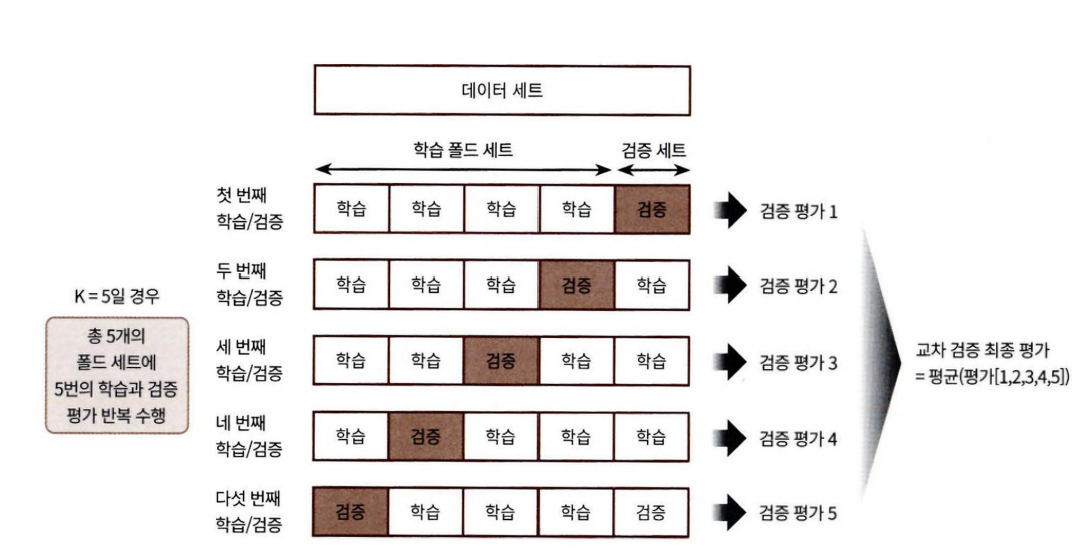

사이킷런에서의 K 폴드 교차 검증 - KFOLD & StratifiedKFOLD 클래스 제공

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

iris=load_iris()
features=iris.data
label=iris.target
dt_clf=DecisionTreeClassifier(random_state=156)

# 5개의 폴드 세트로  분리하는 KFOLD 객체와 폴드 세트별 정확도를 담을 리스트 객체 생성
kfold=KFold(n_splits=5)
cv_accuracy=[]
print('붓꽃 데이터 세트 크기:', features.shape[0])

붓꽃 데이터 세트 크기: 150


- KFold 객체는 split()을 호출하면 학습용/검증용 데이터로 분할할 수 있는 인덱스를 반환

In [19]:
n_iter = 0

# KFold 객체의 split()를 호출하면 폴드별 학습용, 검증용 테스트의 로우 인덱스를 array로 반환
for train_index, test_index in kfold.split(features):

  # kfold.split( )으로 반환된 인덱스를 이용해 학습용, 검증용 테스트 데이터 추출
  X_train, X_test = features[train_index], features[test_index]
  y_train, y_test = label[train_index], label[test_index]

  #학습 및 예측
  dt_clf.fit(X_train, y_train)
  pred = dt_clf.predict(X_test)
  n_iter += 1

  # 반복 시마다 정확도 측정
  accuracy = np.round(accuracy_score(y_test, pred), 4)
  train_size = X_train.shape[0]
  test_size = X_test.shape[0]
  print('\n#{0} 교차 검증 정확도 :{1}, 학습 데이터 크기: {2}, 검증 데이터 크기: {3}'
    .format(n_iter, accuracy, train_size, test_size))
  print('#{0} 검증 세트 인덱스:{1}'.format(n_iter, test_index))
  cv_accuracy.append(accuracy)

# 개별 iteration별 정확도를 합하여 평균 정확도 계산
print('\n## 평균 검증 정확도:', np.mean(cv_accuracy))


#1 교차 검증 정확도 :1.0, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#1 검증 세트 인덱스:[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

#2 교차 검증 정확도 :0.9667, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#2 검증 세트 인덱스:[30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

#3 교차 검증 정확도 :0.8667, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#3 검증 세트 인덱스:[60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

#4 교차 검증 정확도 :0.9333, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#4 검증 세트 인덱스:[ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

#5 교차 검증 정확도 :0.7333, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#5 검증 세트 인덱스:[120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]

## 평균 검증 정확도: 0.9


# Stratified K 폴드

:  불균형한(imbalanced) 분포도를 가진 레이블(결정 클래스) 데이터 집합을 위한 K 폴드 방식

In [20]:
import pandas as pd

iris=load_iris()
iris_df=pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['label']=iris.target
iris_df['label'].value_counts()

,count
label,
0,50
1,50
2,50


In [21]:
kfold=KFold(n_splits=3)
n_iter=0
for train_index, test_index in kfold.split(iris_df):
  n_iter+=1
  label_train=iris_df['label'].iloc[train_index]
  label_test=iris_df['label'].iloc[test_index]
  print('## 교차 검증:{0}'.format(n_iter))
  print('학습 레이블 데이터 분포:\n', label_train.value_counts())
  print('검증 레이블 데이터 분포:\n', label_test.value_counts())

## 교차 검증:1
학습 레이블 데이터 분포:
 label
1    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    50
Name: count, dtype: int64
## 교차 검증:2
학습 레이블 데이터 분포:
 label
0    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    50
Name: count, dtype: int64
## 교차 검증:3
학습 레이블 데이터 분포:
 label
0    50
1    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
2    50
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import StratifiedKFold

skf=StratifiedKFold(n_splits=3)
n_iter=0

for train_index, test_index in skf.split(iris_df, iris_df['label']):
  n_iter+=1
  label_train=iris_df['label'].iloc[train_index]
  label_test=iris_df['label'].iloc[test_index]
  print('##교차 검증:{0}'.format(n_iter))
  print('학습 레이블 데이터 분포:\n', label_train.value_counts())
  print('검증 레이블 데이터 분포:\n', label_test.value_counts())

##교차 검증:1
학습 레이블 데이터 분포:
 label
2    34
0    33
1    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    17
1    17
2    16
Name: count, dtype: int64
##교차 검증:2
학습 레이블 데이터 분포:
 label
1    34
0    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    17
2    17
1    16
Name: count, dtype: int64
##교차 검증:3
학습 레이블 데이터 분포:
 label
0    34
1    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    17
2    17
0    16
Name: count, dtype: int64


StratifiedKFold를 이용해 데이터를 분리

In [26]:
dt_clf = DecisionTreeClassifier(random_state=156)

skfold = StratifiedKFold(n_splits=3)
n_iter=0
cv_accuracy=[]

# StratifiedKFold의 split() 호출 시 반드시  레이블 데이터 세트도 추가 입력 필요
for train_index, test_index in skfold.split(features, label):

  # split()으로 반환된 인덱스를 이용해 학습용, 검증용 테스트 데이터 추출
  X_train, X_test=features[train_index], features[test_index]
  y_train, y_test=label[train_index], label[test_index]

  # 학습 및 예측
  dt_clf.fit(X_train, y_train)
  pred=dt_clf.predict(X_test)


  # 반복 시마다 정확도 측정
  n_iter+=1
  accuracy=np.round(accuracy_score(y_test, pred), 4)
  train_size=X_train.shape[0]
  test_size=X_test.shape[0]
  print('\n#{0} 교차 검증 정확도 :{1}, 학습 데이터 크기: {2}, 검증 데이터 크기: {3}'.format(n_iter, accuracy, train_size, test_size))
  print('#{0} 검증 세트 인덱스:{1}'.format(n_iter, test_index))
  cv_accuracy.append(accuracy)


# 교차 검증별 정확도 및 평균 정확도 계산
print('\n## 교차 검증별 정확도:', np.round(cv_accuracy, 4))
print('## 평균 검증 정확도:', np.round(np.mean(cv_accuracy), 4))






#1 교차 검증 정확도 :0.98, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#1 검증 세트 인덱스:[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  50
  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115]

#2 교차 검증 정확도 :0.94, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#2 검증 세트 인덱스:[ 17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82 116 117 118
 119 120 121 122 123 124 125 126 127 128 129 130 131 132]

#3 교차 검증 정확도 :0.98, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#3 검증 세트 인덱스:[ 34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149]

## 교차 검증별 정확도: [0.98 0.94 0.98]
## 평균 검증 정확도: 0.9667


일반적으로 분류(Classification)에서의 교차 검증 = K 폴드 X & Stratified K 폴드 O
- 회귀(Regression)에서는 Stratified K 폴드가 지원되지 않음
  - 회귀의 결정값은 이산값 형태의 레이블이 아니라 연속된 숫자값이기 때문에 결정값 별로 분포를
정하는 의미가 없기 때문임

# 교차 검증을 보다 간편하게 一 cross_val_score()



KFold로 데이터를 학습하고 예측하는 코드를 보면
- 1. 폴드 세트를 설정
- 2. for 루프에서 반복으로 학습 및 테스트 데이터의 인덱스를 추출
- 3. 반복적으로 학습과 예측을 수행하고 예측 성능을 반환

-> cross_val_score( )는 이런 일련의 과정을 한꺼번에 수행해주는 API

- estimator는 사이킷런의 분류 알고리즘 클래스인 Classifier 또는 회귀 알고리즘 클래스인 Regressor
를 의미

- X는 피처 데이터 세트, y는 레이블 데이터 세트, scoring은 예측 성능 평가 지표를 기술, cv는 교차 검증 폴드 수를 의미


In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.datasets import load_iris

iris_data = load_iris()
dt_clf = DecisionTreeClassifier(random_state=156)

data = iris_data.data
label = iris_data.target

# 성능 지표는 정확도(accuracy), 교차 검증 세트는 3개
scores = cross_val_score(dt_clf, data, label, scoring='accuracy',cv=3)
print('교차 검증별 정확도:', np.round(scores, 4))
print('평균 걷증 정확도:', np.round(np.mean(scores), 4))



교차 검증별 정확도: [0.98 0.94 0.98]
평균 걷증 정확도: 0.9667


cf )  cross_validate()
- cross_val_score() = 단 하나의 평가 지표만 가능
- cross_validate() = 여러 개의 평가 지표를 반환 + 학습 데이터에 대한 성능 평가 지표와 수행 시간도 같이 제공

# GridSearchCV - 교차 검증과 최적 하이퍼 파라미터 튜닝을 한 번에

In [29]:
grid_parameters = {'max_depth': [1, 2, 3], 'min_samples_split':[2, 3]}

[ GridSearchCV 클래스의 생성자로 들어가는 주요 파라미터 ]
- estimator： classifier, regressor, pipeline이 사용될 수 있음
- param_grid： key + 리스트 값을 가지는 딕셔너리가 주어짐. estimator의 튜닝을 위해 파라미터명과 사용될 여러 파라미터 값을 지정
- scoring： 예측 성능을 측정할 평가 방법을 지정
  - 보통은 사이킷런의 성능 평가 지표를 지정하는 문자열（예: 정확도의 경우 ‘accuracy’）로 지정하나 별도의 성능 평가 지표 함수도 지정할 수 있음
- cv： 교차 검증을 위해 분할되는 학습/테스트 세트의 개수 지정
- refit： 디폴트가 True이며 True로 생성 시 가장 최적의 하이퍼 파라미터를 찾은 뒤 입력된 estimator 객체를 해당 하이퍼 파라미터로 재학습시킴


In [31]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 데이터를 로딩하고 학습 데이터와 테스트 데이터 분리
iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.2, random_state=121)
dtree = DecisionTreeClassifier()

# ## 파라미터를 딕셔너리 형태로 설정
parameters = {'max_depth':[1, 2, 3], 'min_samples_split':[2, 3]}

- 학습 데이터 세트를 GridSearchCV 객체의 fit(학습 데이터 세트) 메서드에 인자로 입력
- GridSearchCV 객체의 fit(학습 데이터 세트) 메서드를 수행하면 학습 데이터를 cv에 기술된 폴딩 세
트로 분할해 param_grid에 기술된 하이퍼 파라미터를 순차적으로 변경하면서 학습/평가를 수행하고
그 결과를 cv_results_ 속성에 기록
- cv_results_는 gridsearchcv의 결과 세트로서 딕셔너리 형태로 key 값과 리스트 형태의 value 값을 가짐


In [35]:
import pandas as pd

# param_grid의 하이퍼 파라미터를 3개의 train, test set fold로 나누어 테스트 수행 설정
# ## refit=True가 default임. True이면 가장 좋은 파라미터 설정으로 재학습
grid_dtree = GridSearchCV(dtree, param_grid=parameters, cv=3, refit=True)

# 붓꽃 학습 데이터로 param_grid의 하이퍼 파라미터를 순차적으로 학습/평가 .
grid_dtree.fit(X_train, y_train)

# GridSearchCV 결과를 추출해 DataFrame으로 변환
scores_df = pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params', 'mean_test_score', 'rank_test_score', 'split0_test_score', 'split1_test_score', 'split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.700000,5,0.700,0.7,0.70
1,"{'max_depth': 1, 'min_samples_split': 3}",0.700000,5,0.700,0.7,0.70
2,"{'max_depth': 2, 'min_samples_split': 2}",0.958333,3,0.925,1.0,0.95
3,"{'max_depth': 2, 'min_samples_split': 3}",0.958333,3,0.925,1.0,0.95
4,"{'max_depth': 3, 'min_samples_split': 2}",0.975000,1,0.975,1.0,0.95
5,"{'max_depth': 3, 'min_samples_split': 3}",0.975000,1,0.975,1.0,0.95


- params 칼럼에는 수행할 때마다 적용된 개별 하이퍼 파라미터값을 나타냄
- rank_test_socre는 하이퍼 파라미터별로 성능이 좋은 score 순위를 나타냄 - 10| 가장 뛰어난 순위이며 이때의 파라미터가 최적의 하이퍼 파라미터
- mean_test_score는 개별 하이퍼 파라미터별로 CV의 폴딩 테스트 세트에 대해 총 수행한 평가 평균값임

In [36]:
print('GridSearchCV 최적 파라미터:', grid_dtree.best_params_)
print('GridSearchCV 최고 정확도:{0: .4f}' .format(grid_dtree.best_score_))

GridSearchCV 최적 파라미터: {'max_depth': 3, 'min_samples_split': 2}
GridSearchCV 최고 정확도: 0.9750


In [38]:
# GridSearchCV의 refit으로 이미 학습된 estimator 반환
estimator = grid_dtree.best_estimator_

# GridSearchCV의 best_estimator_는 이미 최적 학습이 됐으므로 별도 학습이 필요 없음
pred = estimator.predict(X_test)
print('테스트 데이터 세트 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

테스트 데이터 세트 정확도: 0.9667
